In [ ]:
# ── strategy_a_channel_selection.py ──────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import f_oneway

df = pd.read_csv("EMG-data.csv")

# Keep only 4 gestures (1=rest, 2=fist, 3=wrist flexion, 4=wrist extension)
GESTURES = [1, 2, 3, 4]
df = df[df['class'].isin(GESTURES)].copy()

channels = ['channel1','channel2','channel3','channel4',
            'channel5','channel6','channel7','channel8']

# ── Method 1: One-Way ANOVA separability score ───────────────────────────────
print("=== ANOVA separability per channel ===")
anova_scores = {}
for ch in channels:
    groups = [df[df['class'] == g][ch].values for g in GESTURES]
    f_stat, p_val = f_oneway(*groups)
    anova_scores[ch] = f_stat
    print(f"  {ch}: F={f_stat:.2f}, p={p_val:.4f}")

best_anova = max(anova_scores, key=anova_scores.get)
print(f"\n  Best channel by ANOVA: {best_anova}\n")

# ── Method 2: Cross-validated accuracy per channel ───────────────────────────
# Feature extraction helper (windowed RMS + MAV)
def extract_features_single(series, window=200, step=100):
    features = []
    for i in range(0, len(series) - window, step):
        seg = series[i:i+window]
        rms = np.sqrt(np.mean(seg**2))
        mav = np.mean(np.abs(seg))
        zc  = np.sum(np.diff(np.sign(seg)) != 0)
        wl  = np.sum(np.abs(np.diff(seg)))
        features.append([rms, mav, zc, wl])
    return np.array(features)

def extract_labels(label_series, window=200, step=100):
    labels = []
    for i in range(0, len(label_series) - window, step):
        seg = label_series[i:i+window]
        labels.append(int(pd.Series(seg).mode()[0]))
    return np.array(labels)

print("=== Cross-validated RF accuracy per channel ===")
cv_scores = {}
label_arr = extract_labels(df['class'].values)

for ch in channels:
    X = extract_features_single(df[ch].values)
    y = label_arr[:len(X)]
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    score = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()
    cv_scores[ch] = score
    print(f"  {ch}: CV accuracy = {score:.3f}")

best_cv = max(cv_scores, key=cv_scores.get)
print(f"\n  Best channel by CV accuracy: {best_cv}")
print(f"\n  → RECOMMENDATION: Use '{best_cv}' as your single channel")

=== ANOVA separability per channel ===
  channel1: F=6.23, p=0.0003
  channel2: F=9.11, p=0.0000
  channel3: F=5.89, p=0.0005
  channel4: F=9.06, p=0.0000
  channel5: F=952.04, p=0.0000
  channel6: F=20.73, p=0.0000
  channel7: F=51.62, p=0.0000
  channel8: F=30.69, p=0.0000

  Best channel by ANOVA: channel5

=== Cross-validated RF accuracy per channel ===
  channel1: CV accuracy = 0.584
  channel2: CV accuracy = 0.495
  channel3: CV accuracy = 0.451
  channel4: CV accuracy = 0.513
  channel5: CV accuracy = 0.579
  channel6: CV accuracy = 0.499
  channel7: CV accuracy = 0.572
  channel8: CV accuracy = 0.571

  Best channel by CV accuracy: channel1

  → RECOMMENDATION: Use 'channel1' as your single channel


In [2]:
# ── strategy_b_channel_averaging.py ─────────────────────────────────────────
import pandas as pd
import numpy as np

df = pd.read_csv("EMG-data.csv")
GESTURES = [1, 2, 3, 4]
df = df[df['class'].isin(GESTURES)].copy()

channels = ['channel1','channel2','channel3','channel4',
            'channel5','channel6','channel7','channel8']

# Simple mean across all 8 channels → 1 synthetic signal
df['channel_avg'] = df[channels].mean(axis=1)

# Optional: RMS-combined (gives more weight to high-amplitude channels)
df['channel_rms_combined'] = np.sqrt((df[channels]**2).mean(axis=1))

print("Synthetic channel created.")
print(df[['time', 'channel_avg', 'channel_rms_combined', 'class']].head(10))

# Save for model training
df[['time', 'channel_avg', 'class', 'label']].to_csv("EMG-data-1ch.csv", index=False)
print("Saved: EMG-data-1ch.csv")

Synthetic channel created.
      time  channel_avg  channel_rms_combined  class
2287  2400    -0.000004              0.000008      1
2288  2401    -0.000014              0.000016      1
2289  2402    -0.000014              0.000016      1
2290  2403    -0.000014              0.000016      1
2291  2404    -0.000014              0.000016      1
2292  2405    -0.000014              0.000016      1
2293  2406    -0.000014              0.000016      1
2294  2407    -0.000014              0.000016      1
2295  2408    -0.000014              0.000016      1
2296  2409     0.000004              0.000011      1
Saved: EMG-data-1ch.csv


In [6]:
!pip install pyserial


[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/90.6 kB ? eta -:--:--
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------- -------------------------- 30.7/90.6 kB 1.4 MB/s eta 0:00:01
   ------------------ --------------------- 41.0/90.6 kB 75.7 kB/s eta 0:00:01
   ------------------ --------------------- 41.0/90.6 kB 75.7 kB/s eta 0:00:01
   --------------------------- ------------ 61.4/90.6 kB 102.4 kB/s eta 0:00:01
   ------------------------------------ --- 81.9/90.6 kB 127.5 kB/s

In [1]:
# ── strategy_c_collect_own_data.py ───────────────────────────────────────────
"""
Run this on your PC while your EMG sensor is connected via Arduino (Serial).
Collects labeled EMG data from your single-channel sensor.
"""
import serial
import time
import csv
import numpy as np

PORT       = 'COM3'       # Change to your Arduino port (Linux: '/dev/ttyUSB0')
BAUD       = 115200
SAMPLE_HZ  = 500          # Target sampling rate
GESTURE_DURATION = 5      # seconds per gesture trial
PAUSE_DURATION   = 3      # seconds rest between trials
TRIALS_PER_GESTURE = 10   # number of repetitions

GESTURES = {
    1: "Rest (hand open, relaxed)",
    2: "Fist (hand clenched)",
    3: "Wrist Flexion (bend wrist down)",
    4: "Wrist Extension (bend wrist up)"
}

OUTPUT_FILE = "my_emg_dataset.csv"

def collect_emg(port=PORT, baud=BAUD):
    ser = serial.Serial(port, baud, timeout=1)
    time.sleep(2)  # wait for Arduino to reset

    with open(OUTPUT_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['time_ms', 'emg_raw', 'class', 'trial'])

        for class_id, gesture_name in GESTURES.items():
            print(f"\n{'='*50}")
            print(f"Gesture {class_id}: {gesture_name}")
            print(f"You will perform this gesture {TRIALS_PER_GESTURE} times.")
            input("Press ENTER when ready...")

            for trial in range(1, TRIALS_PER_GESTURE + 1):
                print(f"\n  Trial {trial}/{TRIALS_PER_GESTURE}")
                print(f"  Get ready...", end='', flush=True)
                time.sleep(2)
                print(f"  → PERFORM: {gesture_name}")

                start_time = time.time()
                sample_count = 0

                while (time.time() - start_time) < GESTURE_DURATION:
                    try:
                        line = ser.readline().decode('utf-8').strip()
                        if line.isdigit():
                            emg_val = int(line)
                            timestamp = int((time.time() - start_time) * 1000)
                            writer.writerow([timestamp, emg_val, class_id, trial])
                            sample_count += 1
                    except Exception:
                        pass

                actual_hz = sample_count / GESTURE_DURATION
                print(f"  ✓ Done — {sample_count} samples ({actual_hz:.0f} Hz)")
                print(f"  Rest for {PAUSE_DURATION} seconds...")
                time.sleep(PAUSE_DURATION)

    ser.close()
    print(f"\nDataset saved: {OUTPUT_FILE}")

if __name__ == "__main__":
    collect_emg()


Gesture 1: Rest (hand open, relaxed)
You will perform this gesture 10 times.

  Trial 1/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4716 samples (943 Hz)
  Rest for 3 seconds...

  Trial 2/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4516 samples (903 Hz)
  Rest for 3 seconds...

  Trial 3/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4521 samples (904 Hz)
  Rest for 3 seconds...

  Trial 4/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4533 samples (907 Hz)
  Rest for 3 seconds...

  Trial 5/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4527 samples (905 Hz)
  Rest for 3 seconds...

  Trial 6/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4508 samples (902 Hz)
  Rest for 3 seconds...

  Trial 7/10
  Get ready...  → PERFORM: Rest (hand open, relaxed)
  ✓ Done — 4516 samples (903 Hz)
  Rest for 3 seconds...

  Trial 8/10
  Get ready...  → PERFORM: Rest (hand op

Features shape: (9942, 6)  |  Classes: [1 2 3 4]

Model: Random Forest
              precision    recall  f1-score   support

        Rest       0.63      0.63      0.63       501
        Fist       0.38      0.42      0.40       485
  Wrist Flex       0.36      0.31      0.33       500
   Wrist Ext       0.42      0.43      0.42       503

    accuracy                           0.45      1989
   macro avg       0.45      0.45      0.45      1989
weighted avg       0.45      0.45      0.45      1989


Model: SVM (RBF)
              precision    recall  f1-score   support

        Rest       0.65      0.69      0.67       501
        Fist       0.39      0.31      0.34       485
  Wrist Flex       0.41      0.36      0.38       500
   Wrist Ext       0.47      0.58      0.52       503

    accuracy                           0.49      1989
   macro avg       0.48      0.49      0.48      1989
weighted avg       0.48      0.49      0.48      1989



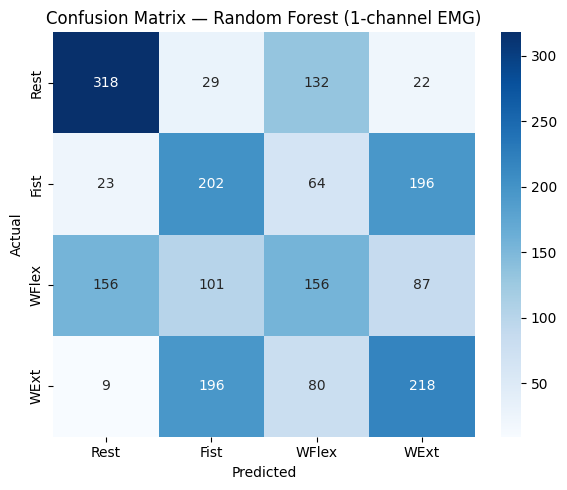


Models saved: emg_rf_model.pkl, emg_scaler.pkl


In [1]:
# ── full_pipeline_1ch.py ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("EMG-data.csv")
GESTURES = [1, 2, 3, 4]
df = df[df['class'].isin(GESTURES)].copy()

# Use Strategy A: best channel (replace 'channel3' with result from selection)
BEST_CHANNEL = 'channel3'
signal = df[BEST_CHANNEL].values
labels_raw = df['class'].values

# ── Feature extraction ───────────────────────────────────────────────────────
WINDOW  = 200   # samples (~400ms at 500Hz)
STEP    = 100   # 50% overlap

def extract_features(signal, window=WINDOW, step=STEP):
    rows = []
    for i in range(0, len(signal) - window, step):
        seg = signal[i:i+window]
        rms = np.sqrt(np.mean(seg**2))
        mav = np.mean(np.abs(seg))
        zc  = np.sum(np.diff(np.sign(seg)) != 0)
        wl  = np.sum(np.abs(np.diff(seg)))
        ssc = np.sum(np.diff(np.sign(np.diff(seg))) != 0)
        var = np.var(seg)
        rows.append([rms, mav, zc, wl, ssc, var])
    return np.array(rows), ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']

def majority_label(label_arr, window=WINDOW, step=STEP):
    labs = []
    for i in range(0, len(label_arr) - window, step):
        seg = label_arr[i:i+window]
        labs.append(int(pd.Series(seg).mode()[0]))
    return np.array(labs)

X, feat_names = extract_features(signal)
y = majority_label(labels_raw)
y = y[:len(X)]

print(f"Features shape: {X.shape}  |  Classes: {np.unique(y)}")

# ── Train/test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Train models ─────────────────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':     SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
}

results = {}
for name, clf in models.items():
    if 'SVM' in name:
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred,
          target_names=['Rest','Fist','Wrist Flex','Wrist Ext']))
    results[name] = {'model': clf, 'pred': y_pred}

# ── Confusion matrix plot ────────────────────────────────────────────────────
best_model_name = 'Random Forest'
cm = confusion_matrix(y_test, results[best_model_name]['pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rest','Fist','WFlex','WExt'],
            yticklabels=['Rest','Fist','WFlex','WExt'])
plt.title(f"Confusion Matrix — {best_model_name} (1-channel EMG)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_1ch.png", dpi=150)
plt.show()

# ── Save model ───────────────────────────────────────────────────────────────
joblib.dump(results['Random Forest']['model'], 'emg_rf_model.pkl')
joblib.dump(scaler, 'emg_scaler.pkl')
print("\nModels saved: emg_rf_model.pkl, emg_scaler.pkl")

Dataset loaded: (4237907, 11)
After filtering Rest + Fist: (493248, 11)

Finding best channel...

  channel1: CV accuracy = 91.04%
  channel2: CV accuracy = 85.91%
  channel3: CV accuracy = 86.43%
  channel4: CV accuracy = 91.06%
  channel5: CV accuracy = 80.17%
  channel6: CV accuracy = 86.86%
  channel7: CV accuracy = 94.38%
  channel8: CV accuracy = 92.42%

Best channel: channel7  (CV accuracy: 94.38%)

Finding best K value...
  K=3: test accuracy = 95.85%
  K=5: test accuracy = 95.24%
  K=7: test accuracy = 94.33%
  K=9: test accuracy = 94.33%
  K=11: test accuracy = 94.43%

Best K: 3  (test accuracy: 95.85%)

       FINAL RESULTS
              precision    recall  f1-score   support

        Rest       0.97      0.94      0.96       502
        Fist       0.94      0.97      0.96       485

    accuracy                           0.96       987
   macro avg       0.96      0.96      0.96       987
weighted avg       0.96      0.96      0.96       987

  Overall Accuracy : 95.85%
  

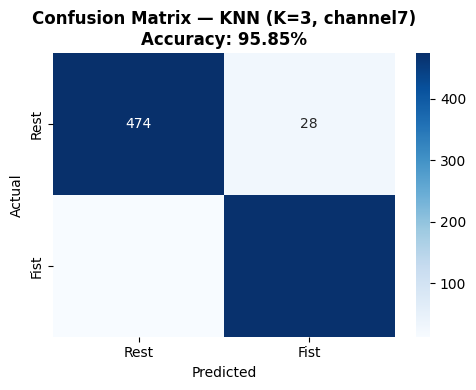

Saved: confusion_matrix.png
Saved: emg_rf_model.pkl  (KNN model)
Saved: emg_scaler.pkl

Done! Now run check_accuracy.py to verify full results.


In [13]:
"""
retrain_knn.py
==============
Run this ONCE to properly retrain KNN on Rest + Fist.
Saves:  emg_rf_model.pkl  (KNN model)
        emg_scaler.pkl    (StandardScaler)

Place this file in the same folder as EMG-data.csv
then run:  python retrain_knn.py
"""

import numpy as np
import pandas as pd
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ─── 1. Load dataset ──────────────────────────────────────────────────────────
df = pd.read_csv("EMG-data.csv")
print(f"Dataset loaded: {df.shape}")

# Keep only Rest (1) and Fist (2)
GESTURES = [1, 2]
df = df[df['class'].isin(GESTURES)].copy()
print(f"After filtering Rest + Fist: {df.shape}\n")

WINDOW = 200
STEP   = 100
GESTURE_NAMES = {1: 'Rest', 2: 'Fist'}

CHANNELS = ['channel1','channel2','channel3','channel4',
            'channel5','channel6','channel7','channel8']

# ─── 2. Feature extraction ────────────────────────────────────────────────────
def extract_features(signal, window=WINDOW, step=STEP):
    rows = []
    for i in range(0, len(signal) - window, step):
        seg = signal[i:i+window]
        rows.append([
            np.sqrt(np.mean(seg**2)),                      # RMS
            np.mean(np.abs(seg)),                           # MAV
            np.sum(np.diff(np.sign(seg)) != 0),            # ZC
            np.sum(np.abs(np.diff(seg))),                  # WL
            np.sum(np.diff(np.sign(np.diff(seg))) != 0),  # SSC
            np.var(seg)                                     # VAR
        ])
    return np.array(rows)

def extract_labels(label_arr, window=WINDOW, step=STEP):
    labs = []
    for i in range(0, len(label_arr) - window, step):
        seg = label_arr[i:i+window]
        labs.append(int(pd.Series(seg).mode()[0]))
    return np.array(labs)

# ─── 3. Find best channel automatically ──────────────────────────────────────
print("Finding best channel...\n")
y_all = extract_labels(df['class'].values)
best_acc, best_ch, best_X, best_y = 0, None, None, None

for ch in CHANNELS:
    if ch not in df.columns:
        continue
    X = extract_features(df[ch].values)
    y = y_all[:len(X)]

    scaler_temp = StandardScaler()
    X_s = scaler_temp.fit_transform(X)

    knn_temp = KNeighborsClassifier(n_neighbors=5)
    score = cross_val_score(knn_temp, X_s, y, cv=5, scoring='accuracy').mean()
    print(f"  {ch}: CV accuracy = {score*100:.2f}%")

    if score > best_acc:
        best_acc = score
        best_ch  = ch
        best_X   = X_s
        best_y   = y

print(f"\nBest channel: {best_ch}  (CV accuracy: {best_acc*100:.2f}%)\n")

# ─── 4. Train final KNN on best channel ──────────────────────────────────────
X_final = extract_features(df[best_ch].values)
y_final = y_all[:len(X_final)]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_final, test_size=0.2, random_state=42, stratify=y_final)

# Find best K value (3, 5, 7, 9)
print("Finding best K value...")
best_k, best_k_acc = 5, 0
for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    print(f"  K={k}: test accuracy = {acc*100:.2f}%")
    if acc > best_k_acc:
        best_k_acc = acc
        best_k = k

print(f"\nBest K: {best_k}  (test accuracy: {best_k_acc*100:.2f}%)\n")

# Train final model with best K
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

# ─── 5. Evaluate ─────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print("=" * 50)
print("       FINAL RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Rest', 'Fist'], labels=[1, 2]))
print(f"  Overall Accuracy : {acc*100:.2f}%")
print(f"  Best Channel     : {best_ch}")
print(f"  Best K           : {best_k}")
print("=" * 50)

# ─── 6. Confusion matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rest', 'Fist'],
            yticklabels=['Rest', 'Fist'])
plt.title(f"Confusion Matrix — KNN (K={best_k}, {best_ch})\nAccuracy: {acc*100:.2f}%",
          fontsize=12, fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# ─── 7. Save model & scaler ──────────────────────────────────────────────────
joblib.dump(model,  "emg_rf_model.pkl")   # keeping same filename so check_accuracy.py still works
joblib.dump(scaler, "emg_scaler.pkl")
print("Saved: emg_rf_model.pkl  (KNN model)")
print("Saved: emg_scaler.pkl")
print(f"\nDone! Now run check_accuracy.py to verify full results.")

Model & scaler loaded
   Classes: [1 2]
Testing all channels...

  channel1: 91.18%
  channel2: 82.28%
  channel3: 83.92%
  channel4: 83.13%
  channel5: 81.59%
  channel6: 87.95%
  channel7: 96.67%
  channel8: 92.07%

Best channel: channel7  →  96.67%

              precision    recall  f1-score   support

        Rest       0.98      0.95      0.97      2508
        Fist       0.95      0.98      0.97      2423

    accuracy                           0.97      4931
   macro avg       0.97      0.97      0.97      4931
weighted avg       0.97      0.97      0.97      4931

  Overall Accuracy  : 96.67%
  Weighted Precision: 96.73%
  Weighted Recall   : 96.67%
  Weighted F1-Score : 96.67%


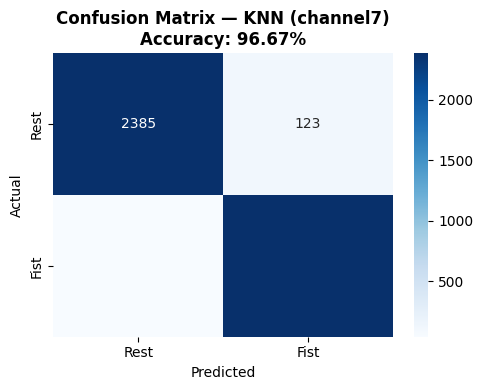

Computing feature importance (~10s)...


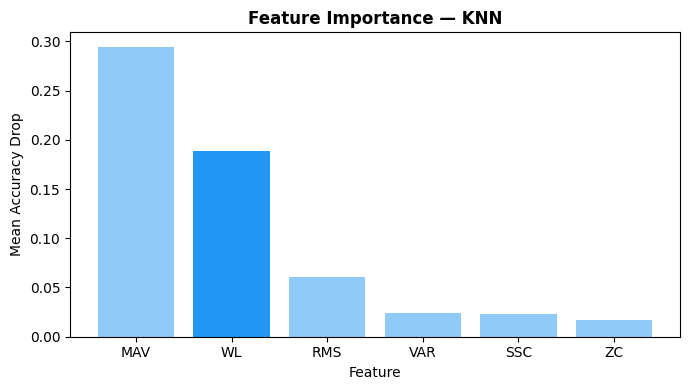


  Per-Gesture Accuracy:
  Gesture          Correct    Total   Accuracy
  ---------------------------------------------
  Rest                2385     2508     95.10%
  Fist                2382     2423     98.31%


In [14]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

model  = joblib.load("emg_rf_model.pkl")
scaler = joblib.load("emg_scaler.pkl")
print("Model & scaler loaded")
print(f"   Classes: {model.classes_}")

df = pd.read_csv("EMG-data.csv")
GESTURES = [1, 2]
df = df[df['class'].isin(GESTURES)].copy()

CHANNELS = ['channel1','channel2','channel3','channel4',
            'channel5','channel6','channel7','channel8']
WINDOW = 200
STEP   = 100
GESTURE_NAMES = {1: 'Rest', 2: 'Fist'}

def extract_features(signal, window=WINDOW, step=STEP):
    rows = []
    for i in range(0, len(signal) - window, step):
        seg = signal[i:i+window]
        rows.append([
            np.sqrt(np.mean(seg**2)),
            np.mean(np.abs(seg)),
            np.sum(np.diff(np.sign(seg)) != 0),
            np.sum(np.abs(np.diff(seg))),
            np.sum(np.diff(np.sign(np.diff(seg))) != 0),
            np.var(seg)
        ])
    return np.array(rows)

def extract_labels(label_arr, window=WINDOW, step=STEP):
    labs = []
    for i in range(0, len(label_arr) - window, step):
        seg = label_arr[i:i+window]
        labs.append(int(pd.Series(seg).mode()[0]))
    return np.array(labs)

y_labels = extract_labels(df['class'].values)

print("Testing all channels...\n")
best_acc, best_ch, best_X, best_y = 0, None, None, None

for ch in CHANNELS:
    if ch not in df.columns:
        continue
    X = extract_features(df[ch].values)
    y = y_labels[:len(X)]
    X_scaled = scaler.transform(X)
    y_pred   = model.predict(X_scaled)
    acc      = accuracy_score(y, y_pred)
    print(f"  {ch}: {acc*100:.2f}%")
    if acc > best_acc:
        best_acc, best_ch, best_X, best_y = acc, ch, X_scaled, y

print(f"\nBest channel: {best_ch}  →  {best_acc*100:.2f}%\n")

y_pred_final = model.predict(best_X)
target_names = ['Rest', 'Fist']

print("=" * 55)
print(classification_report(best_y, y_pred_final, target_names=target_names, labels=[1,2]))

acc  = accuracy_score(best_y, y_pred_final)
prec = precision_score(best_y, y_pred_final, average='weighted')
rec  = recall_score(best_y, y_pred_final, average='weighted')
f1   = f1_score(best_y, y_pred_final, average='weighted')

print(f"  Overall Accuracy  : {acc*100:.2f}%")
print(f"  Weighted Precision: {prec*100:.2f}%")
print(f"  Weighted Recall   : {rec*100:.2f}%")
print(f"  Weighted F1-Score : {f1*100:.2f}%")
print("=" * 55)

cm = confusion_matrix(best_y, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix — KNN ({best_ch})\nAccuracy: {acc*100:.2f}%", fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

from sklearn.inspection import permutation_importance
print("Computing feature importance (~10s)...")
perm = permutation_importance(model, best_X, best_y, n_repeats=10, random_state=42)
feat_names  = ['RMS', 'MAV', 'ZC', 'WL', 'SSC', 'VAR']
sorted_idx  = np.argsort(perm.importances_mean)[::-1]
plt.figure(figsize=(7, 4))
plt.bar([feat_names[i] for i in sorted_idx],
        [perm.importances_mean[i] for i in sorted_idx],
        color=['#2196F3' if i==sorted_idx[0] else '#90CAF9' for i in range(6)])
plt.title("Feature Importance — KNN", fontweight='bold')
plt.xlabel("Feature"); plt.ylabel("Mean Accuracy Drop")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\n  Per-Gesture Accuracy:")
print(f"  {'Gesture':<15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("  " + "-"*45)
for g in [1, 2]:
    mask    = best_y == g
    correct = np.sum(y_pred_final[mask] == g)
    total   = np.sum(mask)
    print(f"  {GESTURE_NAMES[g]:<15} {correct:>8} {total:>8} {correct/total*100:>9.2f}%")